<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB13(11).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from IPython.display import display, Image, clear_output

In [ ]:
# Download config
!wget -q "https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg" \
     -O "yolov3.cfg"

# Download class names
!wget -q "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names" \
     -O "coco.names"

# Download weights (~236MB, takes ~1 min)
!wget -q "https://pjreddie.com/media/files/yolov3.weights" \
     -O "yolov3.weights"

# Verify
for f in ["yolov3.cfg", "coco.names", "yolov3.weights"]:
    size = os.path.getsize(f)
    status = "✓" if size > 1000 else "✗ FAILED"
    print(f"{f}: {size:,} bytes  {status}")

yolov3.cfg: 8,342 bytes  ✓
coco.names: 625 bytes  ✗ FAILED
yolov3.weights: 248,007,048 bytes  ✓


In [ ]:
# Load class names
with open("coco.names") as f:
    CLASSES = [line.strip() for line in f.readlines()]

# Load YOLO
net = cv2.dnn.readNetFromDarknet("yolov3.cfg", "yolov3.weights")
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Get output layers
layer_names   = net.getLayerNames()
output_layers = [layer_names[i-1]
                 for i in net.getUnconnectedOutLayers().flatten()]

print("YOLO loaded!")
print(f"Total classes: {len(CLASSES)}")
print(f"Person class index: {CLASSES.index('person')}")

YOLO loaded!
Total classes: 80
Person class index: 0


In [ ]:
def detect_frame(frame, conf_thresh=0.4, nms_thresh=0.4):
    """
    Run YOLO on one frame.
    Returns: annotated frame, list of detected labels, time taken
    """
    (H, W) = frame.shape[:2]
    start  = time.time()

    # Prepare blob
    blob = cv2.dnn.blobFromImage(frame, 1/255.0,
                                  (416, 416), swapRB=True, crop=False)
    net.setInput(blob)
    outputs = net.forward(output_layers)

    boxes, confidences, class_ids = [], [], []

    for output in outputs:
        for det in output:
            scores    = det[5:]
            class_id  = int(np.argmax(scores))
            confidence= float(scores[class_id])

            if confidence > conf_thresh:
                cx, cy = int(det[0]*W), int(det[1]*H)
                bw, bh = int(det[2]*W), int(det[3]*H)
                x1     = int(cx - bw/2)
                y1     = int(cy - bh/2)
                boxes.append([x1, y1, bw, bh])
                confidences.append(confidence)
                class_ids.append(class_id)

    # Remove duplicate boxes
    indices = cv2.dnn.NMSBoxes(boxes, confidences,
                                conf_thresh, nms_thresh)

    result        = frame.copy()
    detected_labels = []
    person_detected = False

    if len(indices) > 0:
        for i in indices.flatten():
            x1, y1, bw, bh = boxes[i]
            x2, y2  = x1+bw, y1+bh
            label   = CLASSES[class_ids[i]]
            conf    = confidences[i]
            detected_labels.append(label)

            # Red box for person, green for everything else
            if label == "person":
                color = (220, 50, 50)
                person_detected = True
            else:
                color = (50, 200, 50)

            cv2.rectangle(result, (x1,y1), (x2,y2), color, 2)
            cv2.putText(result, f"{label} {conf:.0%}",
                        (x1, max(y1-8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    elapsed = time.time() - start
    fps     = 1.0 / elapsed

    # Draw FPS on frame
    cv2.putText(result, f"FPS: {fps:.1f}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                1.0, (255, 200, 0), 2)

    # Draw ALERT banner if person detected
    if person_detected:
        cv2.rectangle(result, (0,0), (W, 50), (200, 0, 0), -1)
        cv2.putText(result, "ALERT: PERSON DETECTED",
                    (10, 35), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (255, 255, 255), 2)

    return result, detected_labels, fps, elapsed

In [ ]:
import requests

# Free sample video with people walking
url = "https://www.pexels.com/video/854982/download/"
r   = requests.get(url,
                   headers={"User-Agent": "Mozilla/5.0"},
                   stream=True, timeout=30)

with open("security.mp4", "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

size = os.path.getsize("security.mp4")
print(f"Video downloaded: {size:,} bytes")

# Check video info
cap  = cv2.VideoCapture("security.mp4")
fps  = cap.get(cv2.CAP_PROP_FPS)
total= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Video: {w}×{h}, {fps:.1f} FPS, {total} frames")

Video downloaded: 55,776 bytes
Video: 0×0, 0.0 FPS, 0 frames


In [ ]:
import requests, os

os.makedirs("test_frames", exist_ok=True)

# Multiple free images with people — reliable sources
image_urls = [
    "https://images.pexels.com/photos/1464210/pexels-photo-1464210.jpeg?w=800",
    "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg?w=800",
    "https://images.pexels.com/photos/2422293/pexels-photo-2422293.jpeg?w=800",
    "https://images.pexels.com/photos/1770808/pexels-photo-1770808.jpeg?w=800",
    "https://images.pexels.com/photos/3408744/pexels-photo-3408744.jpeg?w=800",
    "https://images.pexels.com/photos/1684187/pexels-photo-1684187.jpeg?w=800",
]

saved = []
for i, url in enumerate(image_urls):
    try:
        r = requests.get(url,
                         headers={"User-Agent": "Mozilla/5.0"},
                         timeout=15)
        if r.status_code == 200 and len(r.content) > 5000:
            path = f"test_frames/frame_{i:02d}.jpg"
            with open(path, "wb") as f:
                f.write(r.content)
            saved.append(path)
            print(f"✓ frame_{i:02d}.jpg  ({len(r.content):,} bytes)")
        else:
            print(f"✗ frame_{i:02d} skipped (bad response)")
    except Exception as e:
        print(f"✗ frame_{i:02d} failed: {e}")

print(f"\nTotal frames ready: {len(saved)}")

✓ frame_00.jpg  (97,170 bytes)
✓ frame_01.jpg  (47,030 bytes)
✓ frame_02.jpg  (59,194 bytes)
✓ frame_03.jpg  (111,917 bytes)
✓ frame_04.jpg  (53,355 bytes)
✓ frame_05.jpg  (68,463 bytes)

Total frames ready: 6


In [ ]:
all_fps       = []
all_times     = []
person_alerts = 0
frame_results = []

print("Processing frames...\n")
print(f"{'Frame':<8} {'FPS':>6} {'Time(ms)':>10} {'Detected'}")
print("-" * 55)

for idx, fpath in enumerate(saved):
    frame = cv2.imread(fpath)

    if frame is None:
        print(f"frame_{idx:02d}  -- could not read, skipping")
        continue

    result, labels, fps_val, elapsed = detect_frame(
        frame, conf_thresh=0.3
    )

    all_fps.append(fps_val)
    all_times.append(elapsed * 1000)

    if "person" in labels:
        person_alerts += 1

    frame_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    frame_results.append((idx, frame_rgb, labels, fps_val))

    print(f"frame_{idx:02d}  "
          f"{fps_val:>6.2f}  "
          f"{elapsed*1000:>8.1f}ms  "
          f"{labels if labels else ['nothing']}")

# Summary
print(f"\n{'='*50}")
if len(all_fps) == 0:
    print("No frames were processed — check image downloads above.")
else:
    print(f"Frames processed : {len(all_fps)}")
    print(f"Average FPS      : {np.mean(all_fps):.2f}")
    print(f"Min FPS          : {np.min(all_fps):.2f}")
    print(f"Max FPS          : {np.max(all_fps):.2f}")
    print(f"Avg time/frame   : {np.mean(all_times):.1f} ms")
    print(f"Person alerts    : {person_alerts}/{len(all_fps)} frames")
    print(f"Detection rate   : {person_alerts/len(all_fps):.0%}")
print(f"{'='*50}")

Processing frames...

Frame       FPS   Time(ms) Detected
-------------------------------------------------------
frame_00    0.34    2957.9ms  ['person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person']
frame_01    1.25     800.2ms  ['dog', 'dog']
frame_02    1.25     797.3ms  ['person', 'person', 'tvmonitor', 'pottedplant', 'person', 'chair', 'laptop', 'pottedplant']
frame_03    1.27     785.7ms  ['person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person']
frame_04    0.95    1056.3ms  ['nothing']
frame_05    0.83    1210.9ms  ['person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'handbag', 'person', 'person', 'person', 'person']

Frames processed : 6


/tmp/ipykernel_4056/135758460.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4056/135758460.py:27: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


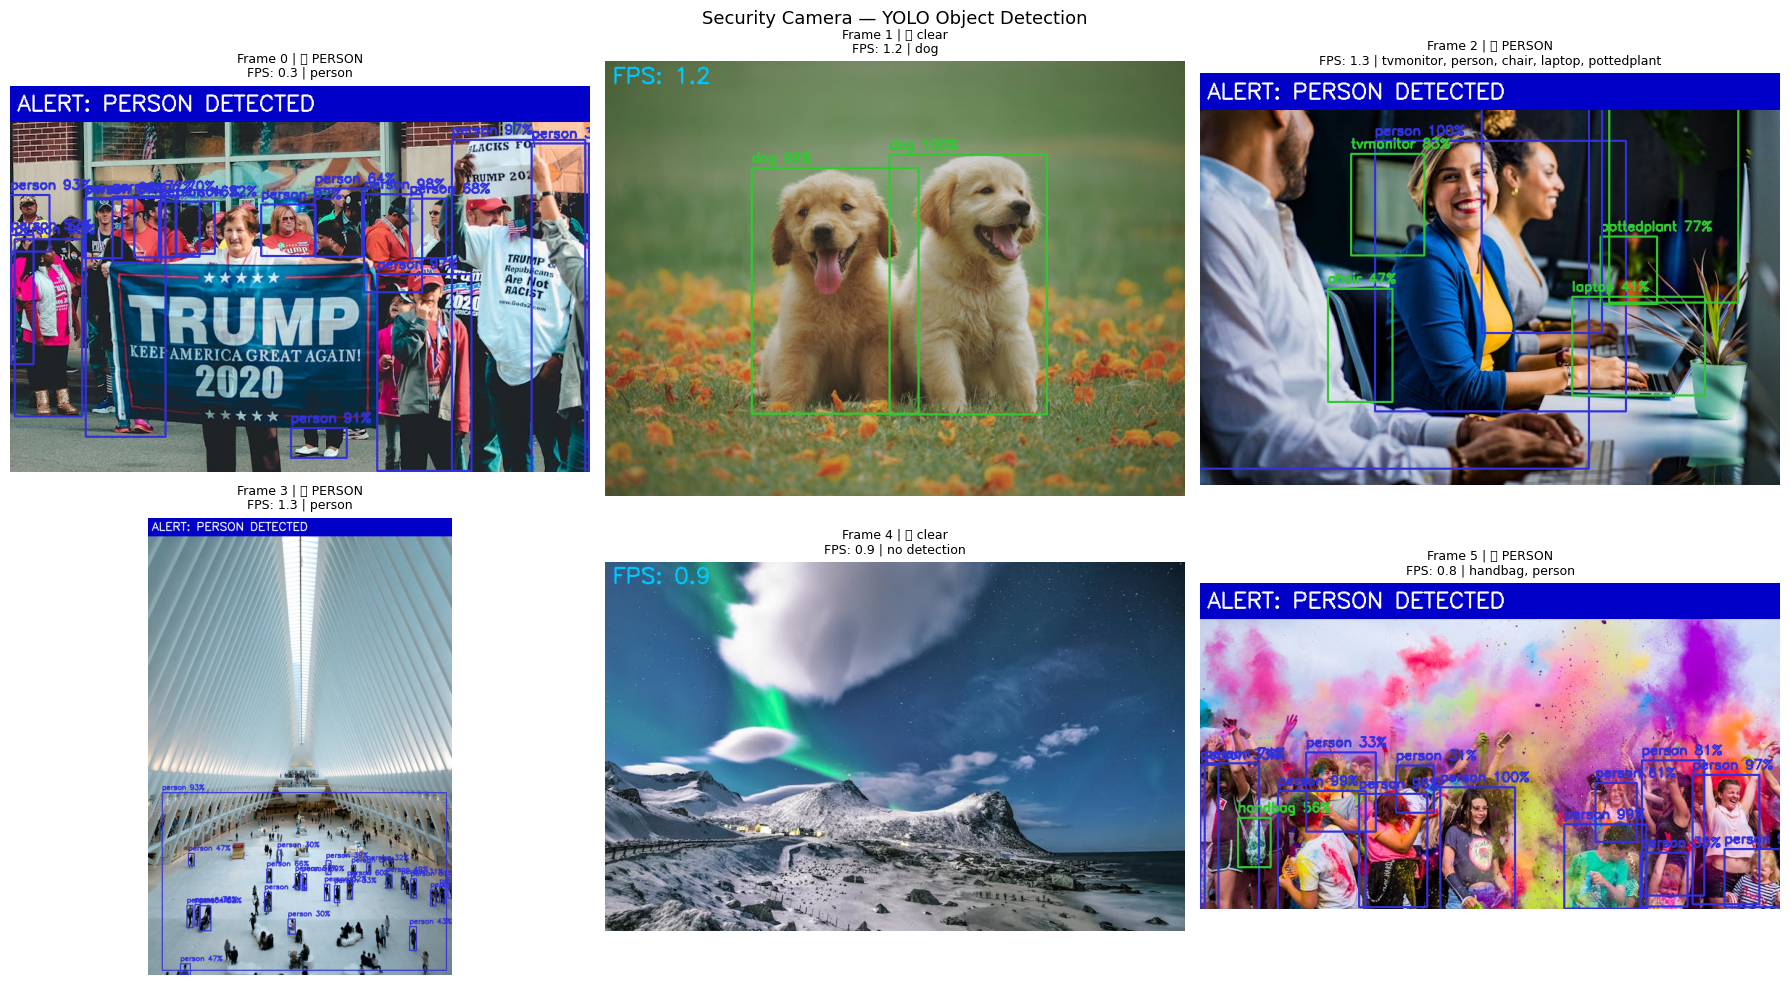

In [ ]:
if len(frame_results) == 0:
    print("No results to display.")
else:
    cols = min(len(frame_results), 3)   # max 3 per row
    rows = (len(frame_results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                              figsize=(cols * 6, rows * 5))
    axes = np.array(axes).flatten()

    for i, (fnum, img, labels, fps_val) in enumerate(frame_results):
        axes[i].imshow(img)
        alert = "🔴 PERSON" if "person" in labels else "🟢 clear"
        axes[i].set_title(
            f"Frame {fnum} | {alert}\n"
            f"FPS: {fps_val:.1f} | "
            f"{', '.join(set(labels)) if labels else 'no detection'}",
            fontsize=9
        )
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(len(frame_results), len(axes)):
        axes[j].axis('off')

    plt.suptitle("Security Camera — YOLO Object Detection", fontsize=13)
    plt.tight_layout(); plt.show()

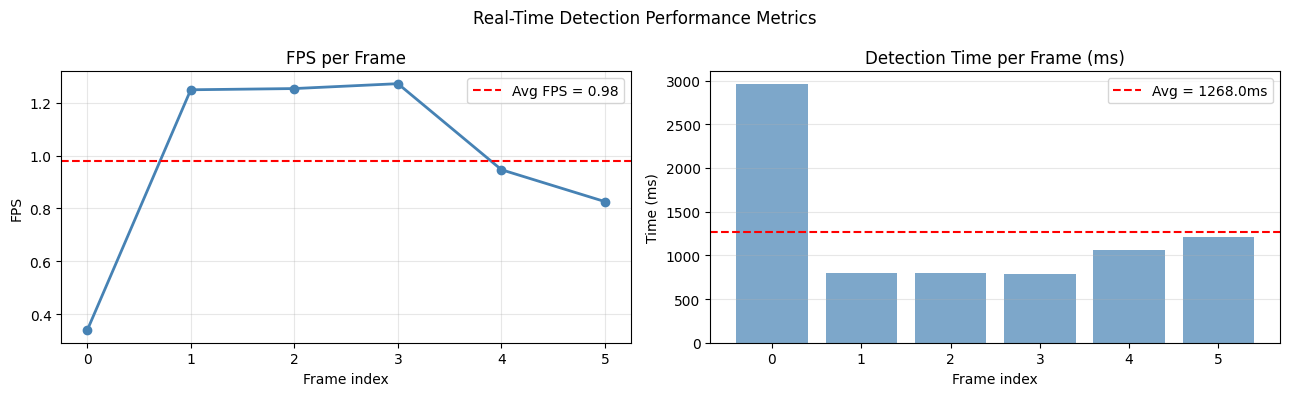

In [ ]:
if len(all_fps) == 0:
    print("No data to plot.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # FPS per frame
    ax1.plot(all_fps, color='steelblue', linewidth=2,
             marker='o', markersize=6)
    ax1.axhline(np.mean(all_fps), color='red', linestyle='--',
                label=f'Avg FPS = {np.mean(all_fps):.2f}')
    ax1.set_title('FPS per Frame')
    ax1.set_xlabel('Frame index')
    ax1.set_ylabel('FPS')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # Time per frame bar chart
    ax2.bar(range(len(all_times)), all_times,
            color='steelblue', alpha=0.7)
    ax2.axhline(np.mean(all_times), color='red', linestyle='--',
                label=f'Avg = {np.mean(all_times):.1f}ms')
    ax2.set_title('Detection Time per Frame (ms)')
    ax2.set_xlabel('Frame index')
    ax2.set_ylabel('Time (ms)')
    ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Real-Time Detection Performance Metrics', fontsize=12)
    plt.tight_layout(); plt.show()